<a href="https://colab.research.google.com/github/selinalee09/Python-Works/blob/main/genetics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub
import os

path=kagglehub.dataset_download("aliyasaly1231/parental-genetics-and-child-trait-prediction-dataset")
os.listdir(path)

100%|██████████| 145k/145k [00:00<00:00, 45.4MB/s]

Extracting files...


['parental_genetics_child_traits.csv']

In [6]:
import pandas as pd
data=os.listdir(path)[0]
df=pd.read_csv(os.path.join(path,data))
df.head(20)

,Family_ID,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Height_cm,Predicted_Child_Blood_Group,Predicted_Health_Risk
0,FAM00001,48,40,163.9,168.6,O+,B+,Green,Brown,Black,Brown,Olive,Light,Multiple,Female,161.9,B+,High
1,FAM00002,34,24,185.5,152.2,A+,A+,Brown,Blue,Black,Brown,Olive,Medium,Hypertension,Female,164.0,A+,Moderate
2,FAM00003,27,36,178.8,158.0,A+,A+,Blue,Blue,Brown,Black,Fair,Olive,Multiple,Female,162.2,A+,High
3,FAM00004,40,26,161.0,157.8,O+,AB-,Brown,Brown,Black,Black,Dark,Dark,Diabetes,Male,161.7,A-,Moderate
4,FAM00005,38,35,175.7,160.7,A-,O+,Hazel,Brown,Brown,Black,Medium,Fair,Asthma,Male,171.7,A+,Moderate
5,FAM00006,42,42,176.3,161.5,O+,O+,Hazel,Green,Red,Blonde,Dark,Medium,Multiple,Male,181.2,O+,High
6,FAM00007,30,31,168.6,163.6,B-,A+,Green,Hazel,Brown,Red,Light,Medium,NaN,Female,161.2,AB-,Low
7,FAM00008,30,42,174.7,149.6,O-,O+,Green,Brown,Blonde,Black,Light,Light,Asthma,Female,155.5,O+,Moderate
8,FAM00009,43,36,167.9,162.0,O+,B+,Hazel,Hazel,Brown,Brown,Fair,Fair,Diabetes,Male,172.9,B-,High
9,FAM00010,55,32,164.2,162.5,A+,B+,Brown,Green,Blonde,Black,Olive,Fair,Diabetes,Male,170.6,AB-,High


In [7]:
df.count()

,0
Family_ID,7000
Father_Age,7000
Mother_Age,7000
Father_Height_cm,7000
Mother_Height_cm,7000
Father_Blood_Group,7000
Mother_Blood_Group,7000
Father_Eye_Color,7000
Mother_Eye_Color,7000
Father_Hair_Color,7000


In [9]:
import numpy as np
min_index = df.select_dtypes(include=['int','float']).min()
max_index = df.select_dtypes(include=['int','float']).max()

pd.concat([min_index.T,max_index.T],axis=1, keys=['min','max'])

,min,max
Father_Age,20.0,55.0
Mother_Age,18.0,50.0
Father_Height_cm,155.0,197.9
Mother_Height_cm,145.0,185.0
Predicted_Child_Height_cm,140.6,198.5


In [13]:
predicted_risk=df.groupby("Predicted_Health_Risk")["Family_Disease_History"].value_counts()

In [14]:
print(predicted_risk)

Predicted_Health_Risk  Family_Disease_History
High                   Heart Disease             425
                       Multiple                  419
                       Diabetes                  378
                       Hypertension              362
                       Asthma                     78
Low                    Asthma                    157
                       Hypertension               91
                       Diabetes                   88
Moderate               Diabetes                  820
                       Hypertension              796
                       Asthma                    444
                       Heart Disease             384
                       Multiple                   97
Name: count, dtype: int64


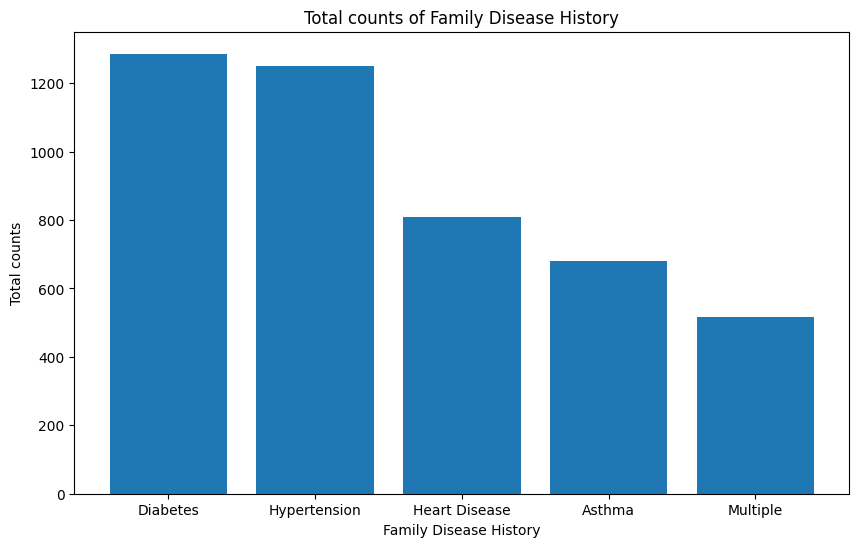

In [17]:
import matplotlib.pyplot as plt
total=predicted_risk.groupby("Family_Disease_History").sum()
total=total.sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.bar(total.index,total.values)
plt.title("Total counts of Family Disease History")
plt.xlabel("Family Disease History")
plt.ylabel("Total counts")
plt.show()



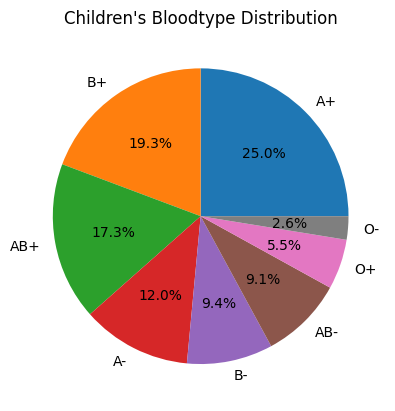

In [21]:
import matplotlib.pyplot as plt
count=df["Predicted_Child_Blood_Group"].value_counts()
plt.pie(count,labels=count.index,autopct="%1.1f%%")
plt.title("Children's Bloodtype Distribution")
plt.show()

<Axes: title={'center': 'Family Disease and Its Predicted Health Risk'}, xlabel='Predicted_Health_Risk', ylabel='Family_Disease_History'>

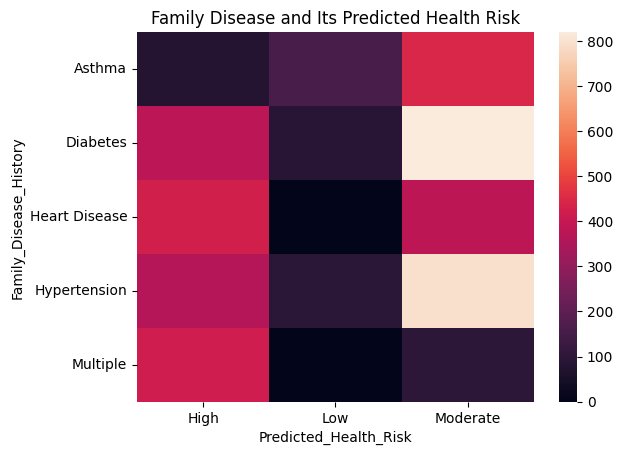

In [29]:
import seaborn as sns
cross=pd.crosstab(df['Family_Disease_History'],df['Predicted_Health_Risk'])
plt.title("Family Disease and Its Predicted Health Risk")
sns.heatmap(cross)


<Axes: title={'center': 'Child Gender and Its Predicted Health Risk'}, xlabel='Predicted_Health_Risk', ylabel='Child_Gender'>

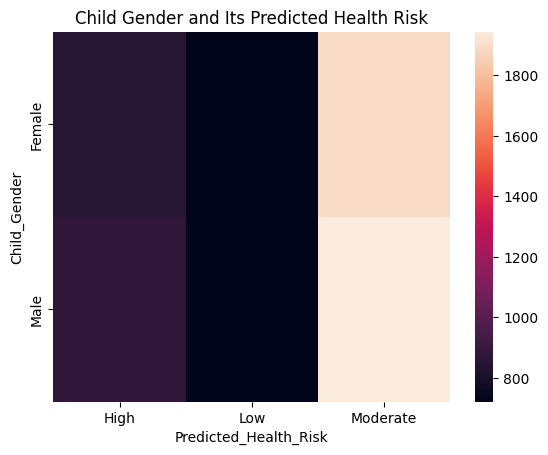

In [30]:
import seaborn as sns
cross=pd.crosstab(df['Child_Gender'],df['Predicted_Health_Risk'])
plt.title("Child Gender and Its Predicted Health Risk")
sns.heatmap(cross)